In [9]:
import numpy as np
import pandas as pd
import seaborn as sns 
from matplotlib import pyplot as plt

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv("gold_monthly.csv")

In [11]:
df.head()

,Date,Price
0,1950-01,34.73
1,1950-02,34.73
2,1950-03,34.73
3,1950-04,34.73
4,1950-05,34.73


In [12]:
df.shape

(847, 2)

In [20]:
print(f"Data range of gold prices available from - {df.loc[:,"Date"][0]} to {df.loc[:,"Date"][len(df)-1]}")

Data range of gold prices available from - 1950-01 to 2020-07


In [24]:
date = pd.date_range(start="1/1/1950", periods=len(df), freq="M")

In [22]:
date = pd.date_range(start = "1/1/1950" , end = "8/1/2021", freq = "M")
date 

DatetimeIndex(['1950-01-31', '1950-02-28', '1950-03-31', '1950-04-30',
               '1950-05-31', '1950-06-30', '1950-07-31', '1950-08-31',
               '1950-09-30', '1950-10-31',
               ...
               '2020-10-31', '2020-11-30', '2020-12-31', '2021-01-31',
               '2021-02-28', '2021-03-31', '2021-04-30', '2021-05-31',
               '2021-06-30', '2021-07-31'],
              dtype='datetime64[ns]', length=859, freq='ME')

In [25]:
df["month"] = date
df.drop("Date", axis =1, inplace = True)
df = df.set_index("month")
df.head()

,Price
month,
1950-01-31,34.73
1950-02-28,34.73
1950-03-31,34.73
1950-04-30,34.73
1950-05-31,34.73


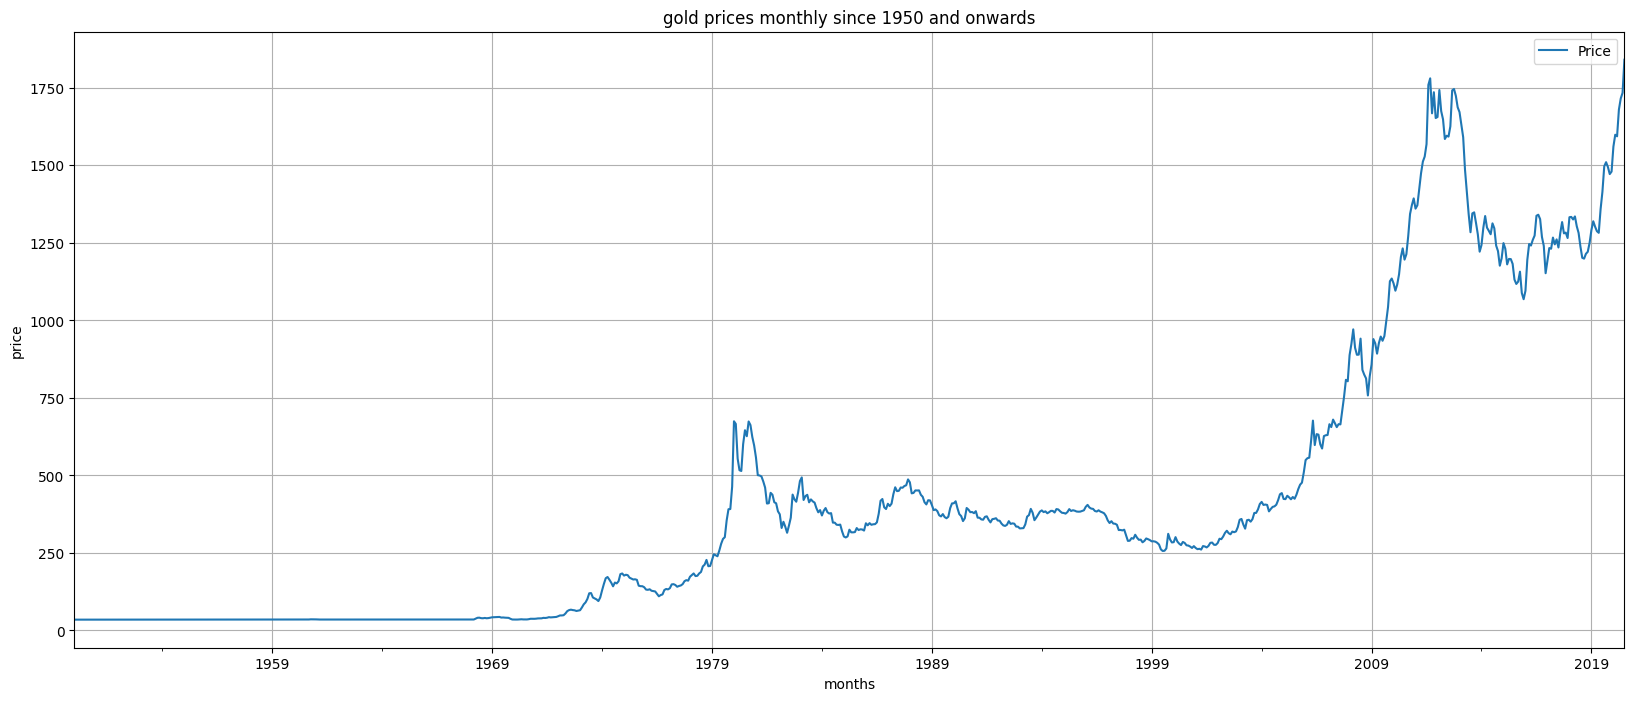

In [26]:
df.plot(figsize = (20,8))
plt.title ("gold prices monthly since 1950 and onwards")
plt.xlabel("months")
plt.ylabel("price")
plt.grid()

In [27]:
round(df.describe(), 3)

,Price
count,847.000
mean,416.557
std,453.665
min,34.490
25%,35.190
50%,319.622
75%,447.029
max,1840.807


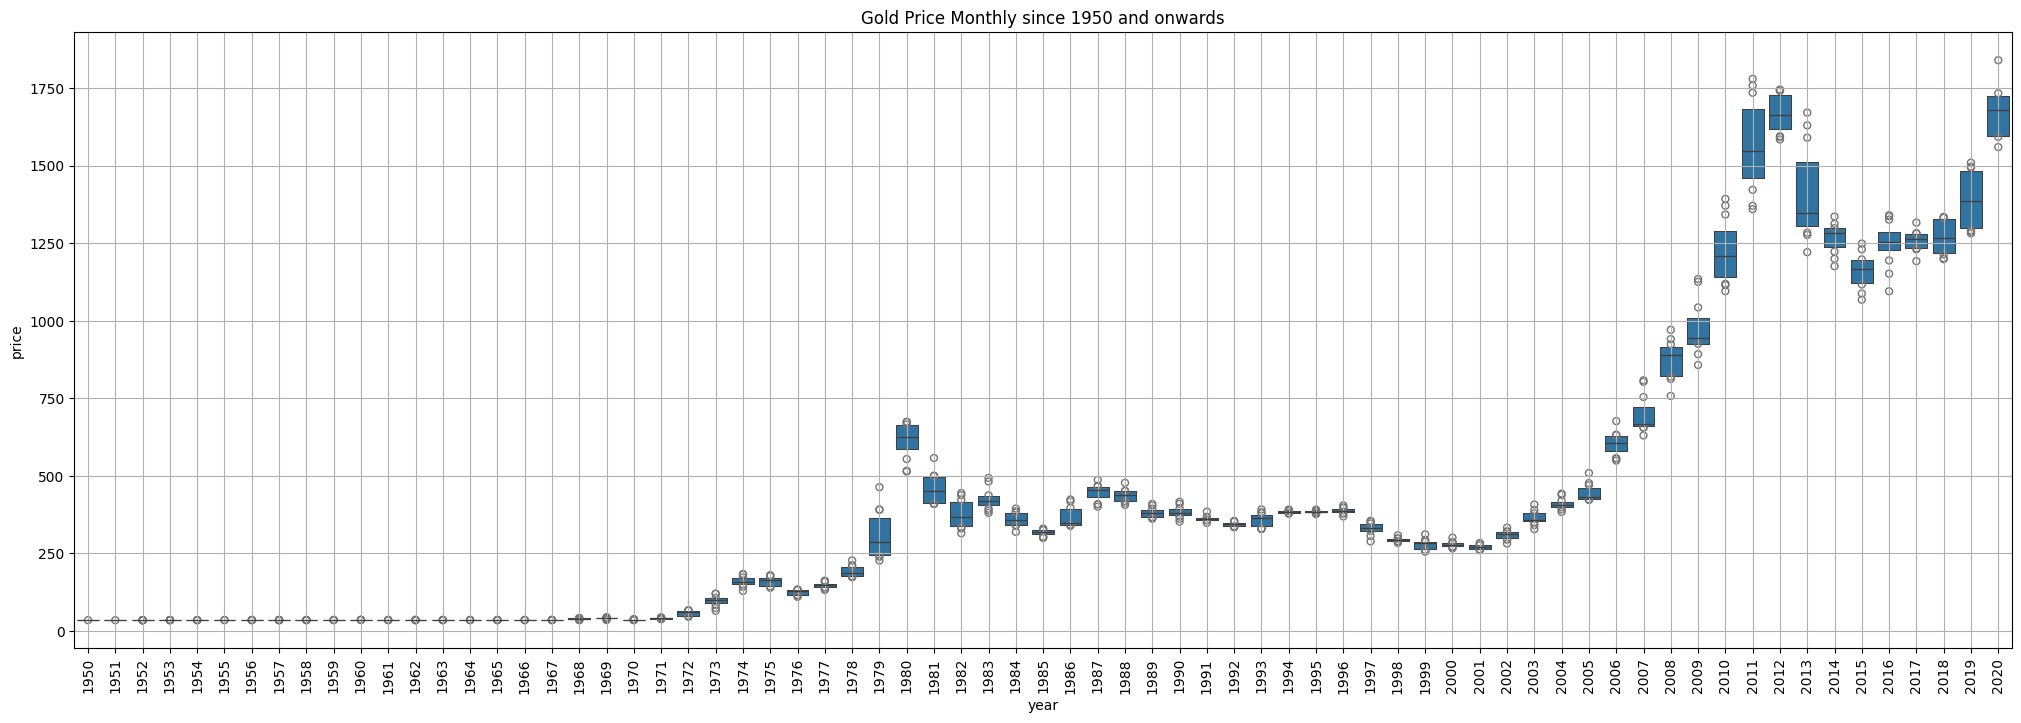

In [28]:
_, ax= plt.subplots(figsize=(25,8))
sns.boxenplot(x= df.index.year, y = df.values[:,0], ax = ax)
plt.title("Gold Price Monthly since 1950 and onwards")
plt.xlabel("year")
plt.ylabel("price")
plt.xticks(rotation = 90)
plt.grid();

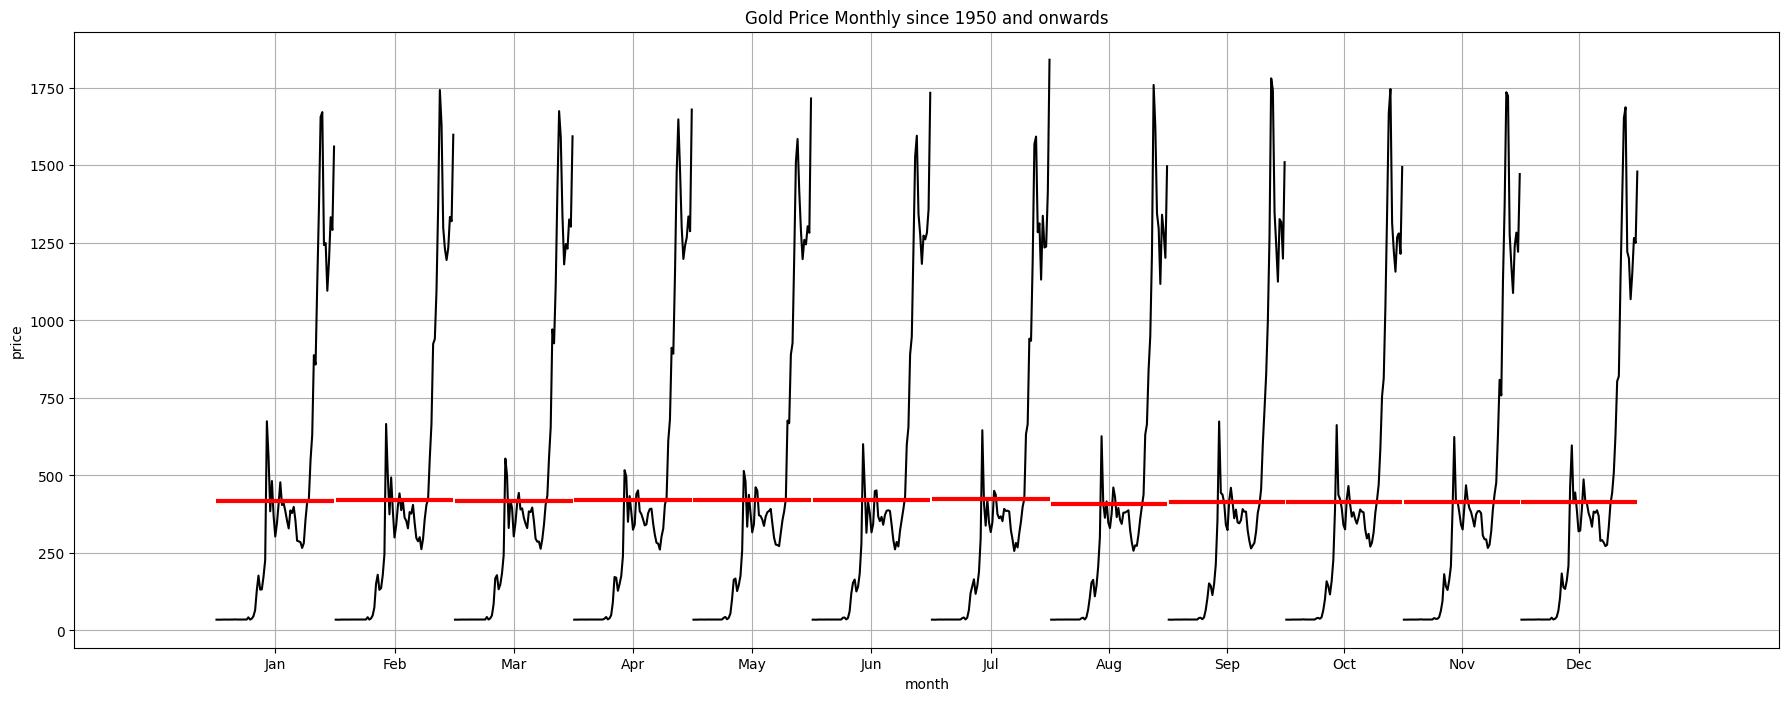

In [29]:
from statsmodels.graphics.tsaplots import month_plot

fig, ax = plt.subplots(figsize = (22,8))
month_plot(df, ylabel= "gold price", ax = ax)
plt.title("Gold Price Monthly since 1950 and onwards")
plt.xlabel("month")
plt.ylabel("price")
plt.grid();

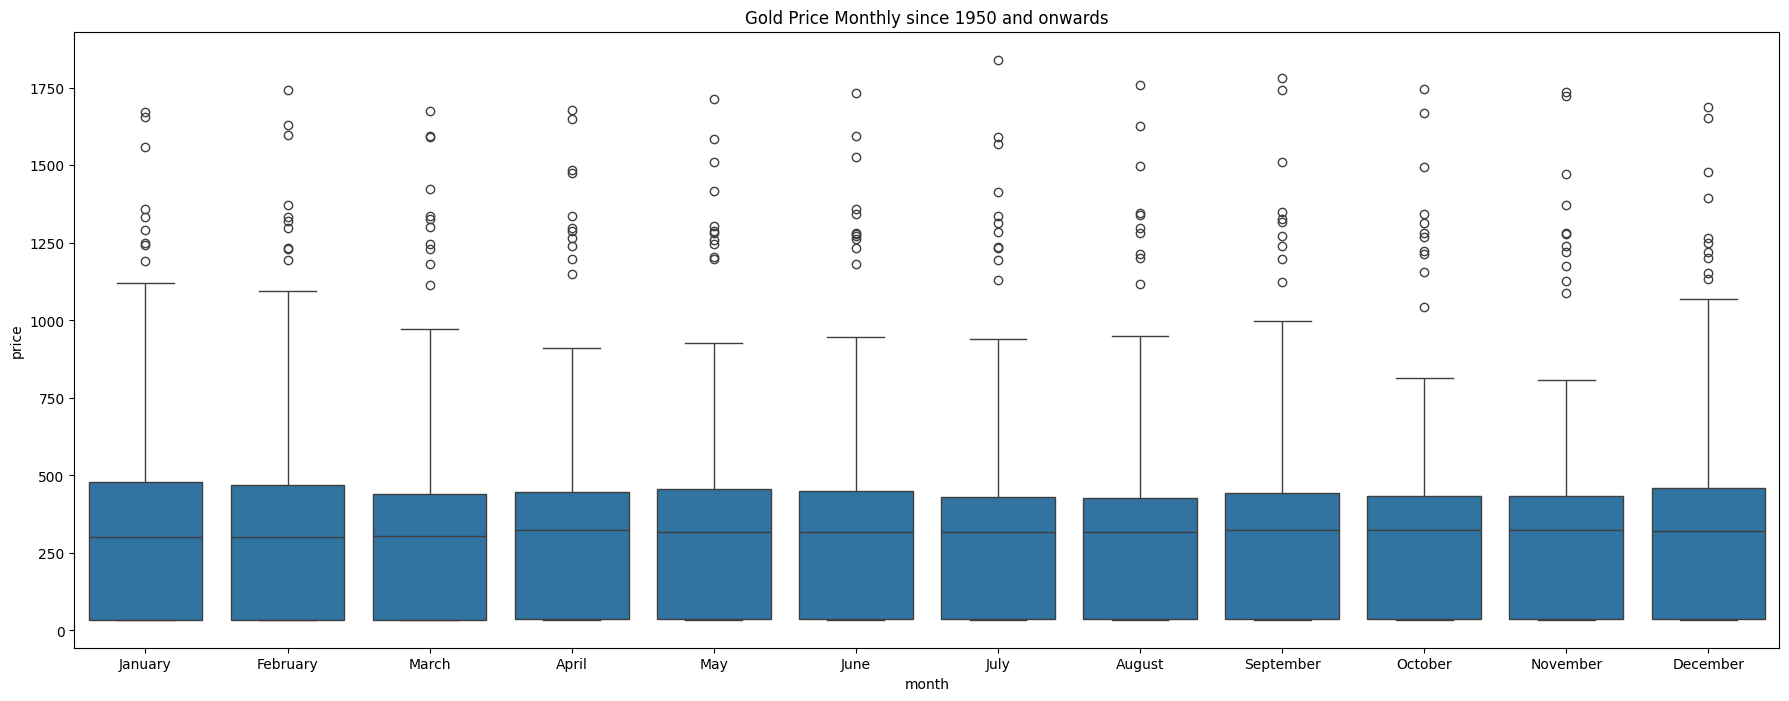

In [30]:
_, ax = plt.subplots(figsize = (22,8))
sns.boxplot(x = df.index.month_name(), y = df.values[:,0], ax = ax)
plt.title("Gold Price Monthly since 1950 and onwards")
plt.xlabel("month")
plt.ylabel("price")
plt.show();

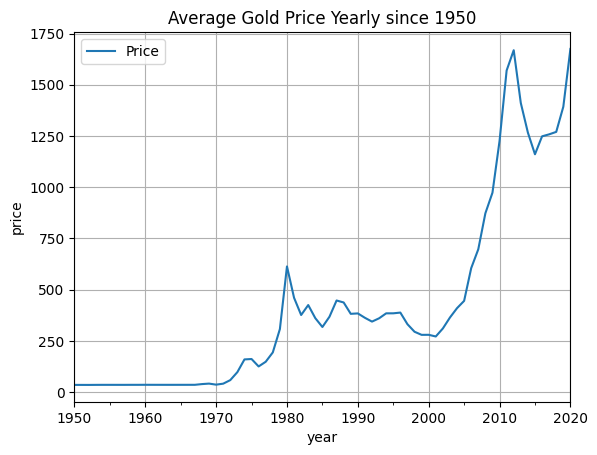

In [31]:
df_yearly_sum = df.resample("A").mean()
df_yearly_sum.plot();
plt.title("Average Gold Price Yearly since 1950")
plt.xlabel("year")
plt.ylabel("price")
plt.grid();

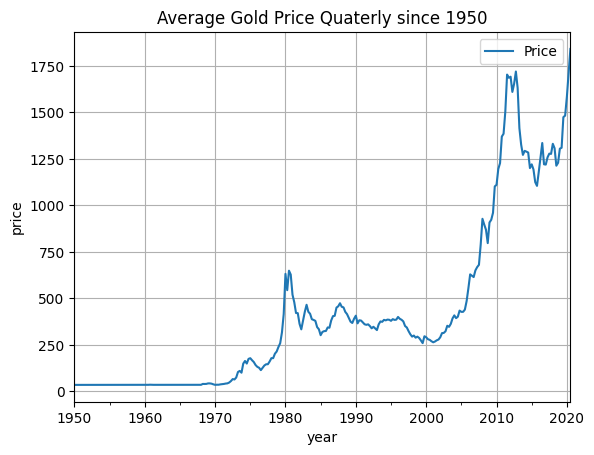

In [32]:
df_quaterly_sum = df.resample("Q").mean()
df_quaterly_sum.plot();
plt.title("Average Gold Price Quaterly since 1950")
plt.xlabel("year")
plt.ylabel("price")
plt.grid();

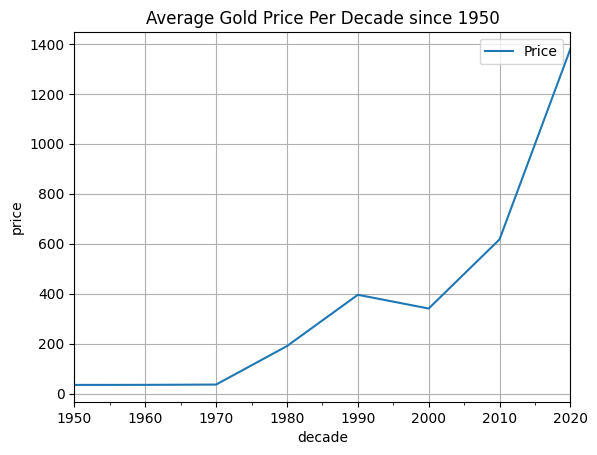

In [33]:
df_decade_sum = df.resample("10Y").mean()
df_decade_sum.plot();
plt.title("Average Gold Price Per Decade since 1950")
plt.xlabel("decade")
plt.ylabel("price")
plt.grid();

In [34]:
df_1 = df.groupby(df.index.year).mean().rename(columns = {"Price" : "Mean"})
df_1 = df_1.merge(df.groupby(df.index.year).std().rename(columns = {"Price" : "Std"}), left_index= True, right_index = True)
df_1["Cov_pct"] = ((df_1["Std"]/df_1["Mean"])* 100).round(2)
df_1.head()

,Mean,Std,Cov_pct
month,,,
1950,34.729167,0.002887,0.01
1951,34.717500,0.020057,0.06
1952,34.628333,0.117538,0.34
1953,34.879167,0.056481,0.16
1954,35.020000,0.082792,0.24


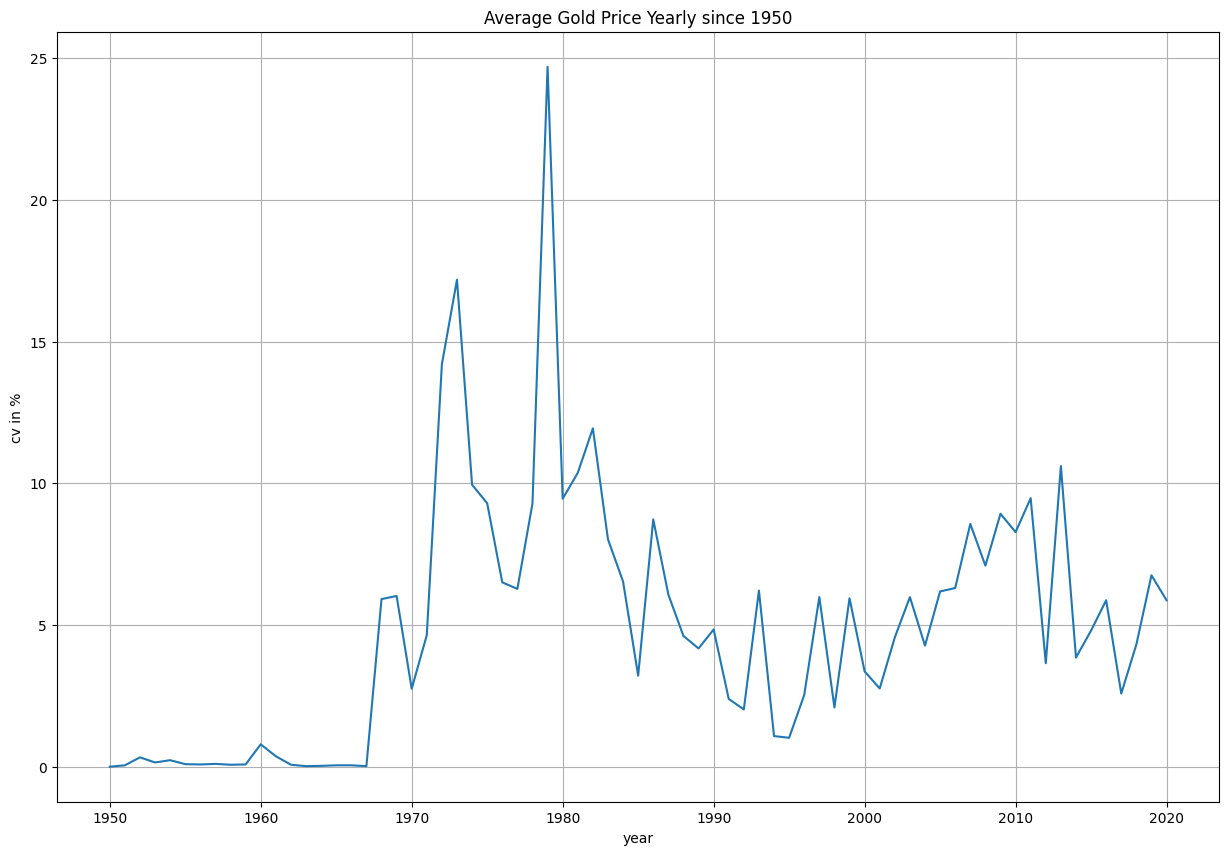

In [35]:
fig, ax= plt.subplots(figsize= (15,10))
df_1["Cov_pct"].plot();
plt.title("Average Gold Price Yearly since 1950")
plt.xlabel("year")
plt.ylabel("cv in %")
plt.grid();


In [36]:
train = df[df.index.year <= 2015]
test = df[df.index.year > 2015]

In [37]:
print(train.shape)
print(test.shape)

(792, 1)
(55, 1)


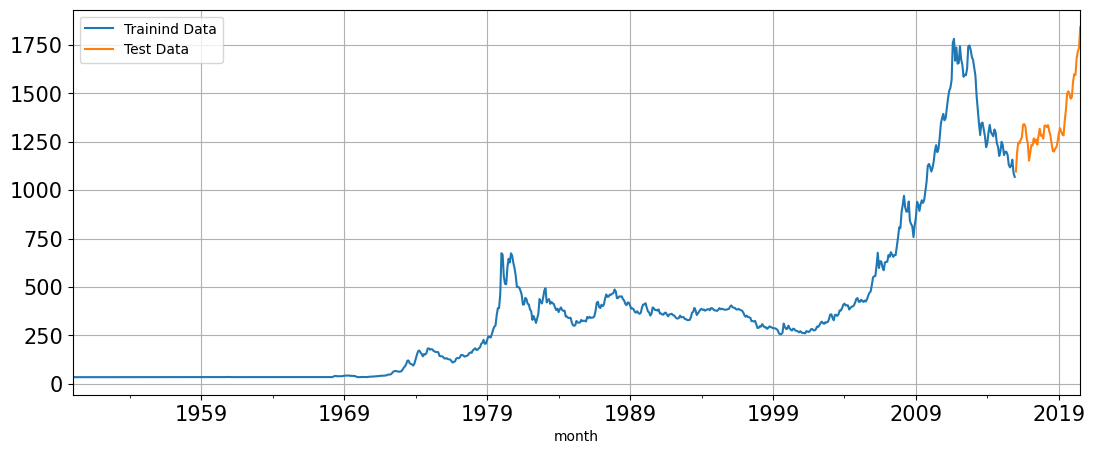

In [38]:
train["Price"].plot(figsize=(13,5), fontsize = 15)
test["Price"].plot(figsize = (13,5), fontsize = 15)
plt.grid()
plt.legend(["Trainind Data", "Test Data"])
plt.show()

In [39]:
train_time = [i + 1 for i in range(len(train))]
test_time = [i + len(train)+ 1 for i in range(len(test))]
len(train_time), len(test_time)

(792, 55)

In [40]:
LR_train = train.copy()
LR_test = test.copy()

In [41]:
LR_train["time"] = train_time
LR_test["time"] = test_time

In [42]:
lr = LinearRegression()
lr.fit(LR_train[["time"]], LR_train["Price"].values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


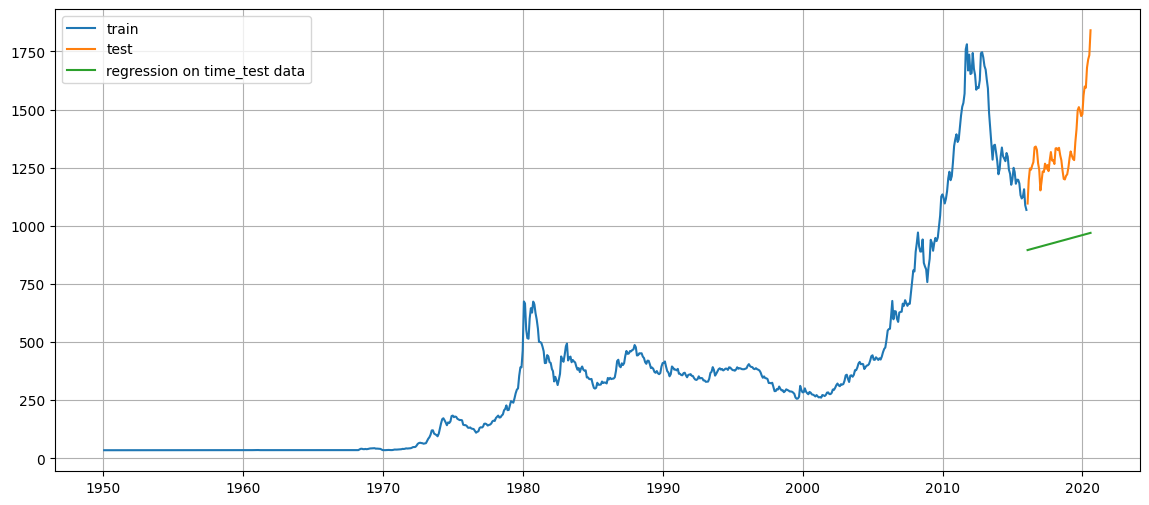

In [43]:
test_predictions_model1 = lr.predict(LR_test[["time"]])
LR_test["forecast"] = test_predictions_model1

plt.figure(figsize = (14,6))
plt.plot(train["Price"], label = "train")
plt.plot(test["Price"], label = "test")
plt.plot(LR_test["forecast"], label = "regression on time_test data")
plt.legend(loc = "best")
plt.grid()

In [44]:
def mape(actual, prediction):
     return round((np.mean(abs(actual-prediction)/ actual))*100, 2)

In [45]:
mape_model1_test = mape(test["Price"]. values,test_predictions_model1)
print("MAPE is %3.3f"%(mape_model1_test),"%")

MAPE is 29.760 %


In [46]:
results = pd.DataFrame({"Test Mape(%)":[mape_model1_test]}, index = ["RegressionOnTime"])
results

,Test Mape(%)
RegressionOnTime,29.76


In [47]:
Naive_train = train.copy()
Naive_test = test.copy()

In [48]:
Naive_test["naive"] = np.asarray(train["Price"])[len(np.asarray(train["Price"])) -1]
Naive_test["naive"].head()

month
2016-01-31    1068.317
2016-02-29    1068.317
2016-03-31    1068.317
2016-04-30    1068.317
2016-05-31    1068.317
Name: naive, dtype: float64

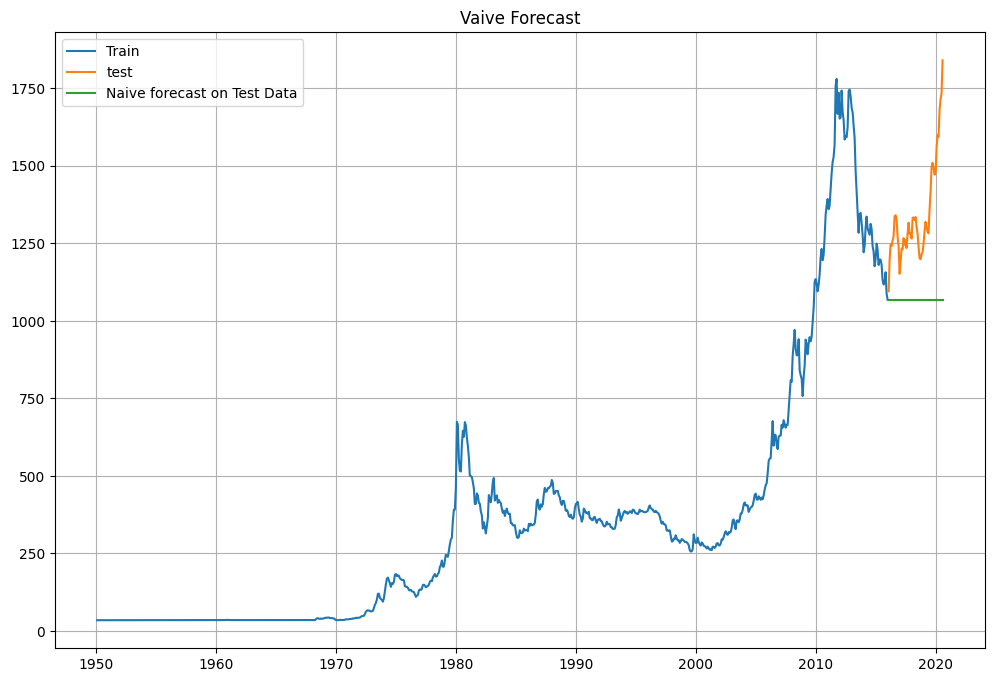

In [49]:
plt.figure(figsize = (12,8))
plt.plot(Naive_train["Price"], label = "Train")
plt.plot(test["Price"], label = "test")
plt.plot(Naive_test["naive"], label = "Naive forecast on Test Data")
plt.legend(loc = "best")
plt.title("Vaive Forecast")
plt.grid()

In [50]:
mape_model2_test = mape(test["Price"]. values,Naive_test["naive"].values)
print("For Naive Forecast on the Test Data, MAPE is %3.3f"%(mape_model1_test),"%")


For Naive Forecast on the Test Data, MAPE is 29.760 %


In [51]:
resultsDF_2 = pd.DataFrame({"Test Mape(%)":[mape_model2_test]}, index = ["NaiveModel"])
results = pd.concat([results, resultsDF_2])
results

,Test Mape(%)
RegressionOnTime,29.76
NaiveModel,19.38


In [55]:
final_model = ExponentialSmoothing(df,
                                   trend = "additive",
                                   seasonal = "additive").fit(smoothing_level = 0.4,
                                                             smoothing_trend = 0.3,
                                                             smoothing_seasonal = 0.6)

In [56]:
Mape_final_model = mape(df["Price"].values, final_model.fittedvalues)
print("MAPE:", Mape_final_model)

MAPE: 17.23


In [57]:
predictions = final_model.forecast(steps=len(test))

In [59]:
pred_df = pd.DataFrame({"lower_CI" : predictions - 1.96*np.std(final_model.resid,ddof = 1),
                       "prediction": predictions,
                       "upper_CI" : predictions +1.96*np.std(final_model.resid,ddof = 1)})
pred_df.head()

,lower_CI,prediction,upper_CI
2020-08-31,1684.722153,1792.873129,1901.024104
2020-09-30,1615.309735,1723.460710,1831.611685
2020-10-31,1538.573100,1646.724075,1754.875050
2020-11-30,1476.765031,1584.916007,1693.066982
2020-12-31,1459.334548,1567.485523,1675.636498


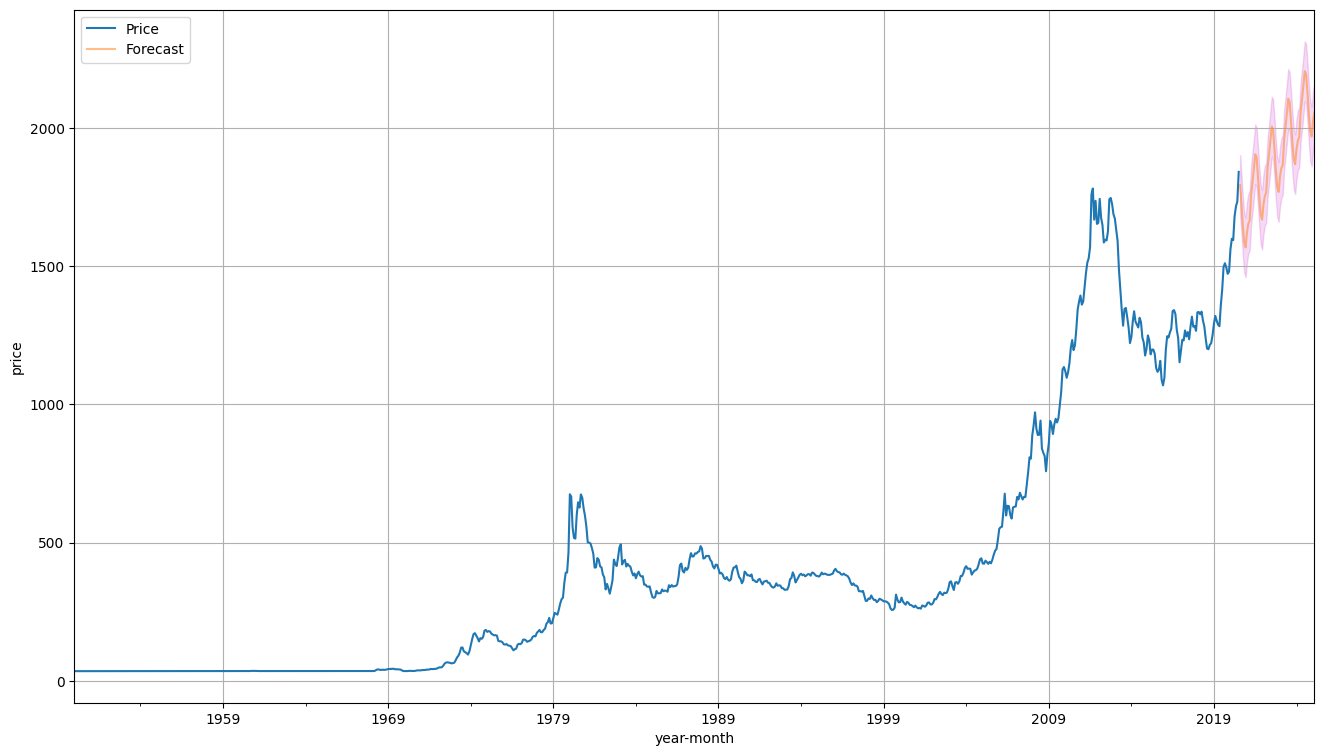

In [62]:
axis = df.plot(label="Actual", figsize=(16,9))

pred_df["prediction"].plot(ax=axis, label="Forecast", alpha=0.5)

axis.fill_between(
    pred_df.index,
    pred_df["lower_CI"],
    pred_df["upper_CI"],
    color="m",
    alpha=0.15
)

axis.set_xlabel("year-month")
axis.set_ylabel("price")

plt.legend(loc="best")
plt.grid()

plt.show()